In [ ]:
from google.colab import files
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import io

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))  # or use the uploaded filename

X = df.drop(columns=['status'])
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

Saving refined_dataset_week4.csv to refined_dataset_week4 (1).csv
(9144, 43) (2286, 43)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# ---- Logistic Regression ----
lr_params = {'C': [0.1, 1, 10]}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_params, cv=3, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)
best_lr = lr_grid.best_estimator_
print("Best LR params:", lr_grid.best_params_)

# ---- Random Forest ----
rf_params = {'n_estimators': [100], 'max_depth': [20, None]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)

# ---- SVM ----
svm_params = {'C': [1, 10]}
svm_grid = GridSearchCV(SVC(probability=True, kernel='rbf', gamma='scale'), svm_params, cv=3, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)
best_svm = svm_grid.best_estimator_
print("Best SVM params:", svm_grid.best_params_)

Best LR params: {'C': 0.1}
Best RF params: {'max_depth': 20, 'n_estimators': 100}
Best SVM params: {'C': 1}



--- Logistic Regression ---
Accuracy: 0.8320
Precision: 0.8255
Recall: 0.8116
F1-score: 0.8185
ROC-AUC: 0.9290

--- Random Forest ---
Accuracy: 0.8303
Precision: 0.8194
Recall: 0.8163
F1-score: 0.8178
ROC-AUC: 0.9211

--- SVM ---
Accuracy: 0.8290
Precision: 0.8177
Recall: 0.8154
F1-score: 0.8165
ROC-AUC: 0.9226


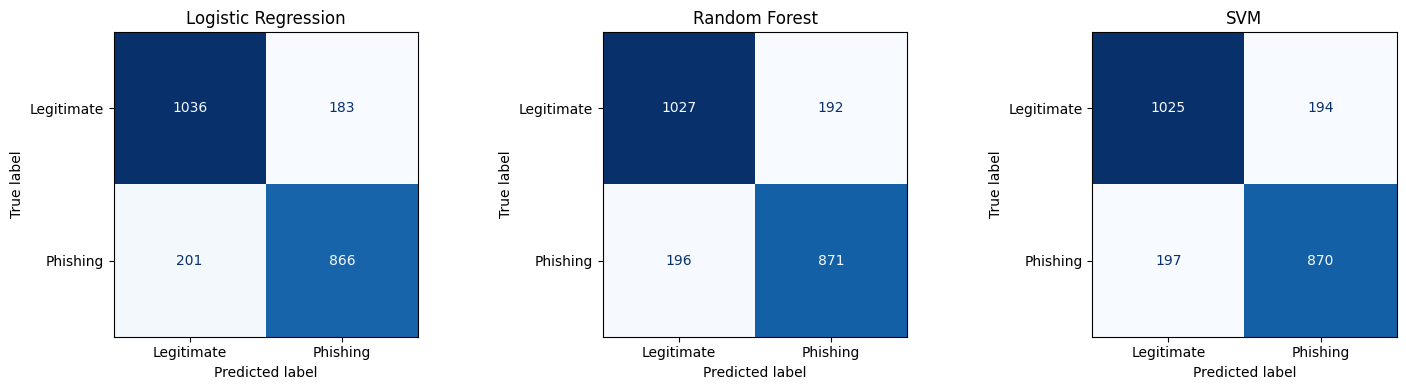

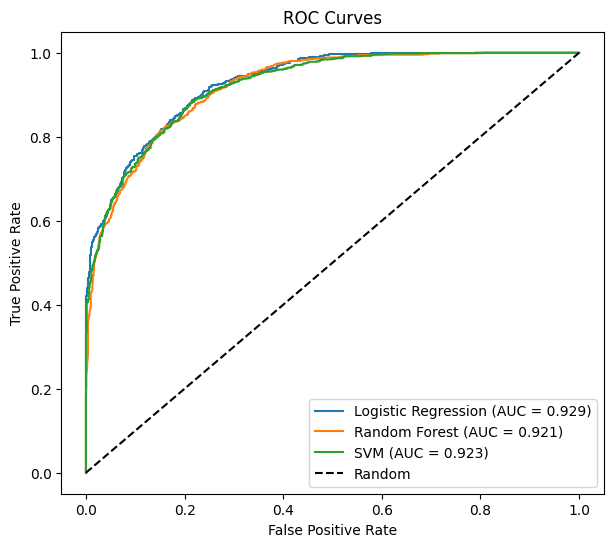

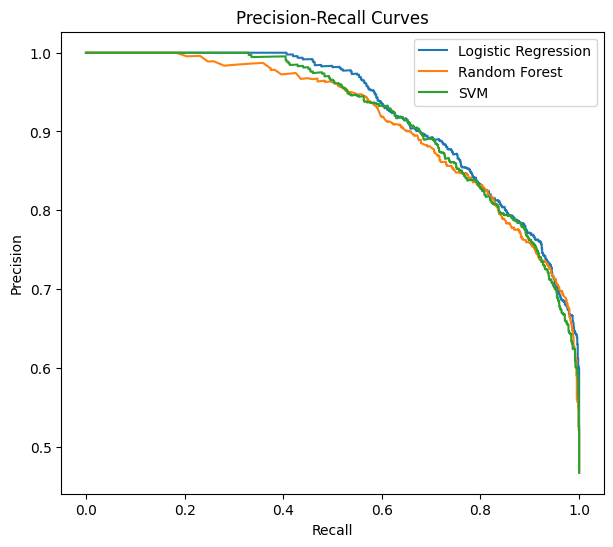


=== Performance Comparison Table ===
                     Accuracy  Precision    Recall  F1-score   ROC-AUC
Logistic Regression  0.832021   0.825548  0.811621  0.818526  0.928982
Random Forest        0.830271   0.819379  0.816307  0.817840  0.921130
SVM                  0.828959   0.817669  0.815370  0.816518  0.922599


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve,
                              ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

models = {
    'Logistic Regression': (best_lr, X_test_scaled),
    'Random Forest': (best_rf, X_test),
    'SVM': (best_svm, X_test_scaled)
}

results = {}

for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    print(f"\n--- {name} ---")
    for metric, value in results[name].items():
        print(f"{metric}: {value:.4f}")

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (model, X_te)) in zip(axes, models.items()):
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

# ROC curves
plt.figure(figsize=(7, 6))
for name, (model, X_te) in models.items():
    y_prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

# Precision-Recall curves
plt.figure(figsize=(7, 6))
for name, (model, X_te) in models.items():
    y_prob = model.predict_proba(X_te)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(rec, prec, label=name)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.savefig('pr_curves.png', dpi=150)
plt.show()

results_df = pd.DataFrame(results).T
print("\n=== Performance Comparison Table ===")
print(results_df)

In [ ]:
!pip install shap -q

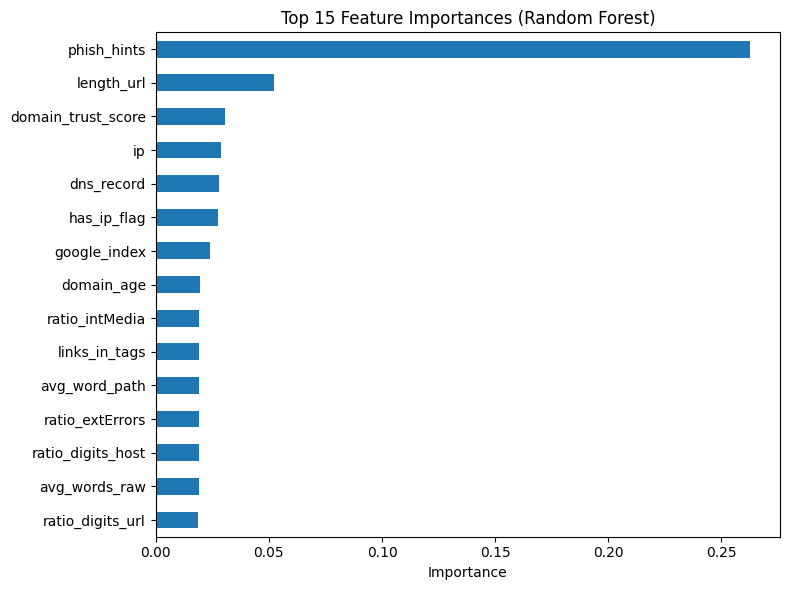

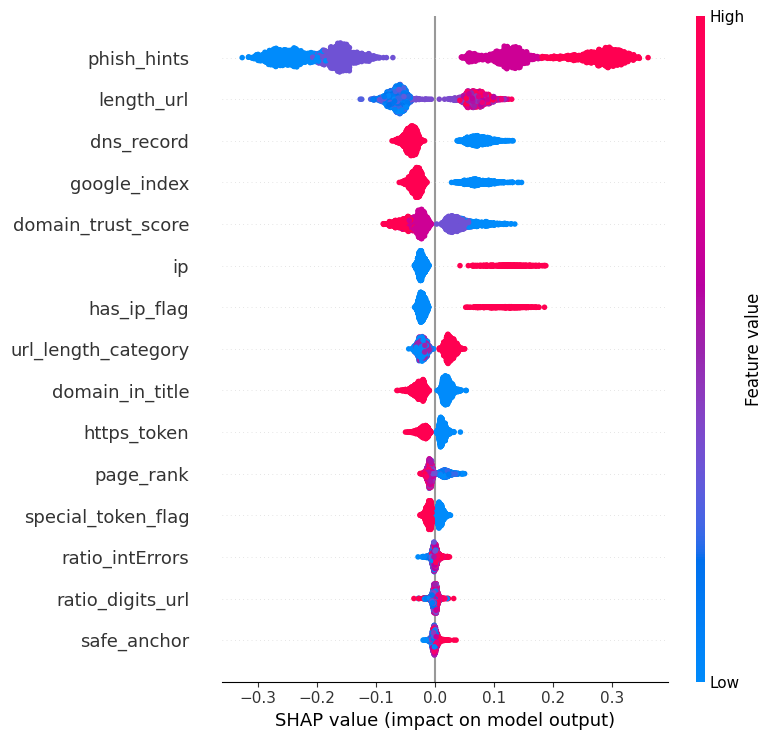

In [ ]:
import shap

# ---- Random Forest feature importance (built-in) ----
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances_sorted.plot(kind='barh')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150)
plt.show()

# ---- SHAP for Random Forest ----
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# shap_values is a list [class0, class1] for binary classifiers in older shap versions
# handle both old and new shap API
if isinstance(shap_values, list):
    shap_vals_plot = shap_values[1]
else:
    shap_vals_plot = shap_values[:, :, 1]

shap.summary_plot(shap_vals_plot, X_test, max_display=15, show=False)
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pickle

# Save the best model (Logistic Regression performed best overall)
with open('best_model_logistic_regression.pkl', 'wb') as f:
    pickle.dump(best_lr, f)

# Also save the scaler — needed to preprocess new data the same way
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
